# Marketing Experiment Analysis: Optimizing Direct-Mail Campaign Engagement

## Business Context

MVP Health Care wanted to evaluate which direct-mail advertising concept would generate stronger engagement for a Medicare Advantage campaign.

Two mailer designs, Option A and Option B, were tested with separate respondent groups. Each respondent evaluated only one version of the mailer.

## Business Question

Which mailer design is more effective at driving customer engagement, and what factors explain differences in response?

## Key Metrics

- Likelihood to Open the Mailer
- Likelihood to Take the Next Step / Contact MVP
- High Response Rate, defined as ratings of 4 or 5 on a 1–5 scale

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", None)

In [5]:
import os

print(os.getcwd())

/Users/liuzhiying/Desktop/marketing_experiment_direct_mail/notebooks


In [6]:
os.listdir("../data")

['surveyB.xlsx', 'surveyA.xlsx', 'valvolinesurvey(1).pdf']

In [8]:
survey_a = pd.read_excel(
    "../data/surveyA.xlsx",
    engine="openpyxl",
    dtype=str
)

survey_b = pd.read_excel(
    "../data/surveyB.xlsx",
    engine="openpyxl",
    dtype=str
)

survey_a.head()

,What is your age?,Are you a resident of the United States?,Gender,Household Income,"If you received this piece of mail at home, how likely would you be to open it?",If You indicated you would be likely to open it. What are the primary reasons for this? (Please select all that apply),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,If You indicated you would be unlikely to open it. What are the primary reasons for this? (Please select all that apply),Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,"After reviewing the full content of the piece, how likely would you be to take the next step (e.g., call the provided number, visit the website, or otherwise contact the company)?",Please rate the amount of information provided in mail piece.,How clear and easy to understand is the information presented in the piece?,How trustworthy and credible does the mail piece appear to you?,"Compared to other mail you have received from healthcare organizations (like insurers, hospitals, or clinics), how would you rate this piece overall?","Now, thinking more broadly, compared to mail you have received from other businesses (e.g., banks, insurance companies, credit card offers), how would you rate this piece?"
0,NaN,NaN,NaN,NaN,NaN,The urgent/important messaging,It was personalized with my name,It looks like an official document,The topic (Healthcare/Medicare) is relevant to me,The unique format caught my attention,Other (please specify),It looks like junk mail,It looks too much like an advertisement,I am not interested in the topic,I have privacy or security concerns,The format does not appeal to me,I do not trust the sender,Other (please specify),NaN,NaN,NaN,NaN,NaN,NaN
1,65 or older,Yes,Female,"$25,000-$49,999",Neutral,NaN,NaN,NaN,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,Very Likely,Too Much Information,Very Unclear,Very Trustworthy,Much better than what I usually receive,About the same as what I usually receive
2,65 or older,Yes,Male,"$75,000-$99,999",Unlikely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Unlikely,Just the Right Amount of Information,Unclear,Slightly Trustworthy,I have not received other healthcare-related mail,Somewhat worse than what I usually receive
3,65 or older,Yes,Female,"$50,000-$74,999",Unlikely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,Very Likely,Too Much Information,Clear,Somewhat Trustworthy,About the same as what I usually receive,Much better than what I usually receive
4,65 or older,Yes,Female,"$25,000-$49,999",Very Likely,NaN,NaN,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very Unlikely,Just the Right Amount of Information,Very Unclear,Not at all Trustworthy,About the same as what I usually receive,Much better than what I usually receive


In [9]:
survey_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 24 columns):
 #   Column                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                               --------------  ----- 
 0   What is your age?                                                                                                                                                                    500 non-null    object
 1   Are you a resident of the United States?                                                                                                                                             500 non-null    object
 2   Gender                                                

In [10]:
survey_a.shape

(501, 24)

In [11]:
survey_a.columns.tolist()

['What is your age?',
 'Are you a resident of the United States?',
 'Gender',
 'Household Income',
 'If you received this piece of mail at home, how likely would you be to open it?',
 'If You indicated you would be likely to open it. What are the primary reasons for this? (Please select all that apply)',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'If You indicated you would be unlikely to open it. What are the primary reasons for this? (Please select all that apply)',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'After reviewing the full content of the piece, how likely would you be to take the next step (e.g., call the provided number, visit the website, or otherwise contact the company)?',
 'Please rate the amount of information provided in mail piece.',
 'How clear and easy to understand is the information presented in the piece?',
 'How trustworthy and credible does the mail piece appear to you?',

In [12]:
survey_a = survey_a.iloc[1:].reset_index(drop=True)
survey_b = survey_b.iloc[1:].reset_index(drop=True)

In [13]:
survey_a.shape
survey_b.shape

(500, 24)

In [16]:
missing = survey_a.isna().sum().sort_values(ascending=False)

missing.to_frame("Missing Values")

,Missing Values
Unnamed: 17,500
Unnamed: 10,500
Unnamed: 14,400
Unnamed: 13,400
Unnamed: 12,399
Unnamed: 15,398
If You indicated you would be likely to open it. What are the primary reasons for this? (Please select all that apply),397
If You indicated you would be unlikely to open it. What are the primary reasons for this? (Please select all that apply),396
Unnamed: 6,391
Unnamed: 8,388


The primary outcome variables and respondent demographics contain no missing values. Missing values are concentrated in conditional follow-up questions.

In [17]:
rename_dict = {
    "What is your age?": "age",
    "Gender": "gender",
    "Household Income": "income",
    "Are you a resident of the United States?": "us_resident",
    "If you received this piece of mail at home, how likely would you be to open it?": "open_intent",
    "After reviewing the full content of the piece, how likely would you be to take the next step (e.g., call the provided number, visit the website, or otherwise contact the company)?": "next_step",
    "Please rate the amount of information provided in mail piece.": "info_amount",
    "How clear and easy to understand is the information presented in the piece?": "clarity",
    "How trustworthy and credible does the mail piece appear to you?": "trust",
    "Compared to other mail you have received from healthcare organizations (like insurers, hospitals, or clinics), how would you rate this piece overall?": "healthcare_comparison",
    "Now, thinking more broadly, compared to mail you have received from other businesses (e.g., banks, insurance companies, credit card offers), how would you rate this piece?": "overall_comparison"
}

In [18]:
survey_a = survey_a.rename(columns=rename_dict)
survey_b = survey_b.rename(columns=rename_dict)

In [19]:
survey_a["option"] = "A"
survey_b["option"] = "B"

survey = pd.concat([survey_a, survey_b], ignore_index=True)

## Data Preparation

The two survey datasets (Option A and Option B) were cleaned and standardized before analysis.

The preprocessing steps included:

- Removed the duplicated header row introduced during Excel export.
- Standardized variable names for readability.
- Added an experiment group indicator (`option`).
- Combined both survey datasets into a single analytical dataset containing 1,000 respondents.

The resulting dataset is used for all subsequent analyses.

## Exploratory Data Analysis (EDA)

In [20]:
survey.shape

(1000, 25)

In [21]:
survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype 
---  ------                                                                                                                    --------------  ----- 
 0   age                                                                                                                       1000 non-null   object
 1   us_resident                                                                                                               1000 non-null   object
 2   gender                                                                                                                    1000 non-null   object
 3   income                                                                                                                    1000 non-null   o

In [22]:
survey.head()

,age,us_resident,gender,income,open_intent,If You indicated you would be likely to open it. What are the primary reasons for this? (Please select all that apply),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,If You indicated you would be unlikely to open it. What are the primary reasons for this? (Please select all that apply),Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,next_step,info_amount,clarity,trust,healthcare_comparison,overall_comparison,option
0,65 or older,Yes,Female,"$25,000-$49,999",Neutral,NaN,NaN,NaN,1,1,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,Very Likely,Too Much Information,Very Unclear,Very Trustworthy,Much better than what I usually receive,About the same as what I usually receive,A
1,65 or older,Yes,Male,"$75,000-$99,999",Unlikely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,Unlikely,Just the Right Amount of Information,Unclear,Slightly Trustworthy,I have not received other healthcare-related mail,Somewhat worse than what I usually receive,A
2,65 or older,Yes,Female,"$50,000-$74,999",Unlikely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,Very Likely,Too Much Information,Clear,Somewhat Trustworthy,About the same as what I usually receive,Much better than what I usually receive,A
3,65 or older,Yes,Female,"$25,000-$49,999",Very Likely,NaN,NaN,1,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very Unlikely,Just the Right Amount of Information,Very Unclear,Not at all Trustworthy,About the same as what I usually receive,Much better than what I usually receive,A
4,65 or older,Yes,Female,"<$25,000",Unlikely,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,NaN,NaN,NaN,Neutral,Too Much Information,Neutral,Not at all Trustworthy,Somewhat better than what I usually receive,Much better than what I usually receive,A


In [23]:
survey["option"].value_counts()

option
A    500
B    500
Name: count, dtype: int64

Both experimental groups contain 500 respondents, indicating a balanced experimental design.

In [24]:
survey["age"].value_counts()

age
65 or older    1000
Name: count, dtype: int64

All respondents were 65 years or older, consistent with the target population for Medicare Advantage marketing.

### Respondent Profile

Before evaluating campaign performance, we first examined whether the respondent sample reflected the intended target audience and whether the two experimental groups were balanced across key demographic characteristics.

In [25]:
survey["gender"].value_counts()

gender
Male      504
Female    496
Name: count, dtype: int64

In [26]:
survey["income"].value_counts()

income
$25,000-$49,999    216
$75,000-$99,999    214
<$25,000           202
$50,000-$74,999    196
$100,000+          172
Name: count, dtype: int64

In [27]:
pd.crosstab(survey["option"], survey["gender"])

gender,Female,Male
option,,
A,248,252
B,248,252


In [28]:
pd.crosstab(survey["option"], survey["income"])

income,"$100,000+","$25,000-$49,999","$50,000-$74,999","$75,000-$99,999","<$25,000"
option,,,,,
A,86,108,98,107,101
B,86,108,98,107,101


In [29]:
from scipy.stats import chi2_contingency

table = pd.crosstab(survey["option"], survey["gender"])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

1.0


Respondents were evenly allocated across experimental groups with identical demographic distributions, indicating that the experiment successfully maintained balance between treatment conditions.

In [30]:
pd.crosstab(
    survey["option"],
    survey["open_intent"]
)

open_intent,Likely,Neutral,Unlikely,Very Likely,Very Unlikely
option,,,,,
A,109,87,110,101,93
B,83,88,115,84,130


Both experimental groups were perfectly balanced across the observed demographic characteristics, suggesting a well-controlled experimental design.

## Experiment Outcomes

In [31]:
pd.crosstab(
    survey["option"],
    survey["open_intent"],
    normalize="index"
).round(3) * 100

open_intent,Likely,Neutral,Unlikely,Very Likely,Very Unlikely
option,,,,,
A,21.8,17.4,22.0,20.2,18.6
B,16.6,17.6,23.0,16.8,26.0


### Initial Observation

Before conducting statistical testing, we compared the response distributions across the two experimental groups.

Option A generated a higher proportion of favorable responses ("Likely" and "Very Likely") while reducing the share of respondents who were "Very Unlikely" to open the mail piece. This suggests that the revised creative may have improved initial engagement.

In [40]:
survey["high_open_intent"] = survey["open_intent"].map({
    "Very Likely": 1,
    "Likely": 1,
    "Neutral": 0,
    "Unlikely": 0,
    "Very Unlikely": 0
})

In [41]:
pd.crosstab(
    survey["option"],
    survey["high_open_intent"],
    normalize="index"
) * 100

high_open_intent,0,1
option,,
A,58.0,42.0
B,66.6,33.4


In [42]:
from statsmodels.stats.proportion import proportions_ztest

success = [
    survey.loc[survey["option"] == "A", "high_open_intent"].sum(),
    survey.loc[survey["option"] == "B", "high_open_intent"].sum()
]

nobs = [
    (survey["option"] == "A").sum(),
    (survey["option"] == "B").sum()
]

z_stat, p_value = proportions_ztest(success, nobs)

print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 2.806
P-value: 0.0050


In [43]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci = confint_proportions_2indep(
    success[0], nobs[0],
    success[1], nobs[1],
    method="wald"
)

print(ci)

(0.026162071649637207, 0.14583792835036272)


To simplify business interpretation, responses of "Likely" and "Very Likely" were grouped into a binary metric (High Open Intent), representing respondents who expressed a positive intention to open the mail piece.

In [44]:
difference = (
    success[0] / nobs[0]
    - success[1] / nobs[1]
)

print(f"High Open Intent (Option A): {success[0]/nobs[0]:.1%}")
print(f"High Open Intent (Option B): {success[1]/nobs[1]:.1%}")
print(f"Difference: {difference:.1%}")
print(f"95% CI: ({ci[0]:.1%}, {ci[1]:.1%})")
print(f"P-value: {p_value:.4f}")

High Open Intent (Option A): 42.0%
High Open Intent (Option B): 33.4%
Difference: 8.6%
95% CI: (2.6%, 14.6%)
P-value: 0.0050


In [45]:
risk_difference = difference
relative_lift = difference / (success[1] / nobs[1])

print(f"Absolute Improvement: {risk_difference:.1%}")
print(f"Relative Lift: {relative_lift:.1%}")

Absolute Improvement: 8.6%
Relative Lift: 25.7%


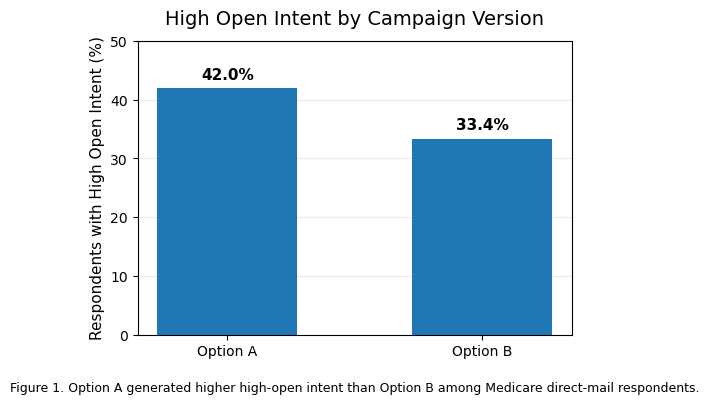

In [47]:
import matplotlib.pyplot as plt

labels = ["Option A", "Option B"]
values = [42.0, 33.4]

plt.figure(figsize=(6.5, 4.2))

bars = plt.bar(labels, values, width=0.55)

plt.title("High Open Intent by Campaign Version", fontsize=14, pad=12)
plt.ylabel("Respondents with High Open Intent (%)", fontsize=11)
plt.ylim(0, 50)

plt.grid(axis="y", alpha=0.25)
plt.gca().set_axisbelow(True)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.text(
    0.5,
    -0.18,
    "Figure 1. Option A generated higher high-open intent than Option B among Medicare direct-mail respondents.",
    ha="center",
    va="center",
    transform=plt.gca().transAxes,
    fontsize=9
)

plt.tight_layout()
plt.savefig("../figures/high_open_intent_by_campaign_version.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Option A increased the share of respondents with high open intent from **33.4%** to **42.0%**, an **absolute improvement of 8.6 percentage points** (95% CI: **2.6–14.6 percentage points**, *p* = **0.005**).

This corresponds to a **25.7% relative increase** in positive engagement compared with Option B.

These findings suggest that Option A is more effective at capturing recipients' initial attention and has the potential to improve direct-mail engagement among the target Medicare audience.

## Conversion Intent

Opening a mail piece is only the first step of customer engagement.

To evaluate whether the improved campaign design also motivates downstream action, we compared respondents' likelihood of taking the next step after reviewing the mail piece.

This analysis assesses whether the stronger initial engagement observed for Option A translates into higher conversion intent.

In [48]:
pd.crosstab(
    survey["option"],
    survey["next_step"],
    normalize="index"
).round(3) * 100

next_step,Likely,Neutral,Unlikely,Very Likely,Very Unlikely
option,,,,,
A,23.4,16.8,18.6,21.0,20.2
B,23.4,16.8,18.6,21.0,20.2


In [49]:
survey[["option", "next_step"]].head(10)

,option,next_step
0,A,Very Likely
1,A,Unlikely
2,A,Very Likely
3,A,Very Unlikely
4,A,Neutral
5,A,Very Unlikely
6,A,Likely
7,A,Very Unlikely
8,A,Unlikely
9,A,Likely


In [50]:
survey.loc[survey["option"]=="A", "next_step"].head()

0      Very Likely
1         Unlikely
2      Very Likely
3    Very Unlikely
4          Neutral
Name: next_step, dtype: object

In [51]:
survey.loc[survey["option"]=="B", "next_step"].head()

500      Very Likely
501         Unlikely
502      Very Likely
503    Very Unlikely
504          Neutral
Name: next_step, dtype: object

In [52]:
survey[["option", "next_step"]].sample(10)

,option,next_step
160,A,Likely
271,A,Neutral
568,B,Very Unlikely
604,B,Unlikely
244,A,Neutral
629,B,Neutral
513,B,Very Likely
498,A,Very Unlikely
373,A,Neutral
7,A,Very Unlikely


In [53]:
survey.loc[survey.option=="A","next_step"].value_counts()

next_step
Likely           117
Very Likely      105
Very Unlikely    101
Unlikely          93
Neutral           84
Name: count, dtype: int64

In [54]:
survey.loc[survey.option=="B","next_step"].value_counts()

next_step
Likely           117
Very Likely      105
Very Unlikely    101
Unlikely          93
Neutral           84
Name: count, dtype: int64

In [55]:
survey["high_conversion_intent"] = survey["next_step"].map({
    "Very Likely": 1,
    "Likely": 1,
    "Neutral": 0,
    "Unlikely": 0,
    "Very Unlikely": 0
})

pd.crosstab(
    survey["option"],
    survey["high_conversion_intent"],
    normalize="index"
).round(3) * 100

high_conversion_intent,0,1
option,,
A,55.6,44.4
B,55.6,44.4


### Interpretation

Unlike open intent, conversion intent was identical across the two campaign versions.

Both Option A and Option B generated a **44.4% high conversion intent rate**, indicating that Option A's stronger first impression did not translate into greater willingness to take the next step.

This suggests that the main difference between the two designs lies in **initial attention**, not in the persuasive strength of the internal message or call-to-action.

## Why did Option A perform better?

Although Option A generated significantly higher opening intent, both campaign versions produced identical conversion intent.

To better understand this pattern, we compared respondents' perceptions of the two mail pieces, including clarity, credibility, information amount, and overall evaluation.

These analyses help explain why Option A attracted greater initial attention without increasing downstream action.

In [56]:
pd.crosstab(
    survey["option"],
    survey["trust"],
    normalize="index"
).round(3) * 100

trust,Extremely Trustworthy,Not at all Trustworthy,Slightly Trustworthy,Somewhat Trustworthy,Very Trustworthy
option,,,,,
A,22.2,20.8,21.6,18.6,16.8
B,22.2,20.8,21.6,18.6,16.8


In [57]:
survey.columns.tolist()

['age',
 'us_resident',
 'gender',
 'income',
 'open_intent',
 'If You indicated you would be likely to open it. What are the primary reasons for this? (Please select all that apply)',
 'Unnamed: 6',
 'Unnamed: 7',
 'Unnamed: 8',
 'Unnamed: 9',
 'Unnamed: 10',
 'If You indicated you would be unlikely to open it. What are the primary reasons for this? (Please select all that apply)',
 'Unnamed: 12',
 'Unnamed: 13',
 'Unnamed: 14',
 'Unnamed: 15',
 'Unnamed: 16',
 'Unnamed: 17',
 'next_step',
 'info_amount',
 'clarity',
 'trust',
 'healthcare_comparison',
 'overall_comparison',
 'option',
 'high_open_intent',
 'high_conversion_intent']

In [58]:
for col in ["clarity", "info_amount", "overall_comparison"]:
    print("\n", col)
    print(pd.crosstab(survey["option"], survey[col], normalize="index"))


 clarity
clarity  Clear  Neutral  Unclear  Very Clear  Very Unclear
option                                                    
A        0.234      0.2    0.184       0.196         0.186
B        0.234      0.2    0.184       0.196         0.186

 info_amount
info_amount  Just the Right Amount of Information  Too Little Information  \
option                                                                      
A                                           0.332                    0.29   
B                                           0.332                    0.29   

info_amount  Too Much Information  
option                             
A                           0.378  
B                           0.378  

 overall_comparison
overall_comparison  About the same as what I usually receive  \
option                                                         
A                                                      0.172   
B                                                      0.172   

overall_c

## Post-Exposure Evaluation

Although Option A generated significantly higher opening intent, we further examined whether respondents evaluated the mail piece differently after reading its full content.

Specifically, we compared four post-exposure metrics:

- Information amount
- Message clarity
- Trustworthiness
- Overall evaluation

| Evaluation Metric | Finding |
|-------------------|-------------------------------|
| Information Amount | Similar across both versions |
| Message Clarity | Similar across both versions |
| Trustworthiness | Similar across both versions |
| Overall Evaluation | Similar across both versions |

### Interpretation

Respondents evaluated both mailer versions similarly once they had reviewed the full content.

While Option A successfully attracted more recipients to open the mail piece, it did not improve perceptions of information quality, message clarity, credibility, or overall satisfaction.

These findings suggest that the redesign primarily improved **initial attention**, rather than the effectiveness of the message itself.

## Business Recommendation

The experiment demonstrates that redesigning the mail piece can significantly improve initial engagement without changing the underlying message.

For future campaigns, Option A should be adopted as the preferred mailer design to maximize opening rates.

However, because downstream evaluations remained unchanged, future optimization efforts should focus on improving the internal messaging, value proposition, and call-to-action to increase conversion after the mail piece is opened.

## Key Takeaways

- Option A increased high open intent from **33.4%** to **42.0%**.
- The improvement was statistically significant (**p = 0.005**).
- Post-exposure perceptions remained consistent across both versions.
- The redesign improved **attention**, but not **persuasion**.